
<h1 align="center">PDDCNN Model</h3>
<h1 align="center">Analysis of the Model</h3>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Put here - the path to the Potato Leaf Disease (PLD) dataset and the path to the working folder
directory_root = '/content/drive/MyDrive/Precision Agriculture/PDDCNN'
dataset_root = '/content/drive/MyDrive/Precision Agriculture/PDDCNN/PLD_3_Classes_256'

##**Imports**

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, auc
from keras.preprocessing.image import ImageDataGenerator
from keras.models import load_model
from sklearn.preprocessing import LabelBinarizer

import numpy as np
import matplotlib.pyplot as plt
import itertools

In [4]:
# Setting all constant parameters
BATCH_SIZE = 32                        # Batch size

""" Input Shape - Image Parameters """
WIDTH = 256
HEIGHT = 256
DEPTH = 3

#**Get Trained Model**

In [5]:
model = load_model(directory_root + '/PDDCNN_with_Augmentation.h5')

In [6]:
# Getting Validation Dataset

val_datagen = ImageDataGenerator(rescale = 1./255)
# Create a generator for prediction
val_generator = val_datagen.flow_from_directory(dataset_root + '/Validation',
                                                                target_size = (HEIGHT, WIDTH),
                                                                batch_size = BATCH_SIZE,
                                                                class_mode = 'categorical',
                                                                shuffle=False)

Found 416 images belonging to 3 classes.


In [7]:
# Getting Testing Dataset

test_datagen = ImageDataGenerator(rescale = 1./255)
# Create a generator for prediction
test_generator = test_datagen.flow_from_directory(dataset_root + '/Testing',
                                                                target_size = (HEIGHT, WIDTH),
                                                                batch_size = BATCH_SIZE,
                                                                class_mode = 'categorical',
                                                                shuffle=False)

Found 405 images belonging to 3 classes.


#**Confusion Matrix**

In [8]:
classes_names = ['Early Blight', 'Healthy', 'Late Blight']

In [11]:
def plot_confusion_matrix(cm, target_names, title='Confusion Matrix', cmap = None):
    """
    plots the confusion matrix
    """

    accuracy = np.trace(cm)/float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize = (6,4))
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title, size = 12)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation = 45, size=12)
        plt.yticks(tick_marks, target_names, size = 11)

    thresh = cm.max() / 2

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, "{:,}".format(cm[i,j]),
               horizontalalignment = "center", fontsize = 16,
               color = "white" if cm[i,j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Label', size = 12)
    plt.xlabel('\nPredicted Label\nAccuracy = {:0.4f} %; Mis-Class = {:0.4f} %'.format(accuracy*100, misclass*100),size=12)
    plt.show()

13/13 [==============================] - 76s 6s/step
*** Classification Report ***
              precision    recall  f1-score   support

Early Blight       1.00      0.99      1.00       163
     Healthy       0.99      1.00      1.00       102
 Late Blight       1.00      1.00      1.00       151

    accuracy                           1.00       416
   macro avg       1.00      1.00      1.00       416
weighted avg       1.00      1.00      1.00       416



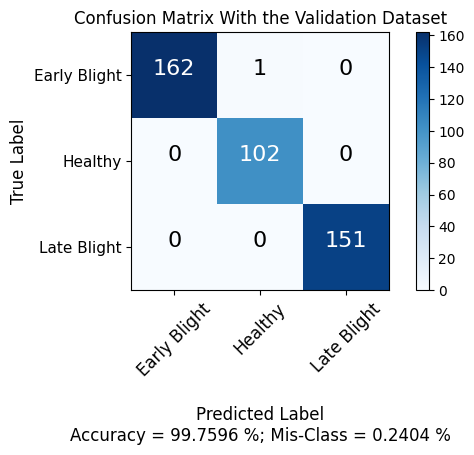

In [12]:
# For the validation dataset
Y_pred_val = model.predict(val_generator, verbose = True)
y_pred_val = np.argmax(Y_pred_val, axis=1)

print('*** Classification Report ***')
print(classification_report(val_generator.classes, y_pred_val, target_names=classes_names))

cm = confusion_matrix(val_generator.classes, y_pred_val)
plot_confusion_matrix(cm,
                     target_names = classes_names,
                     title = "Confusion Matrix With the Validation Dataset")

13/13 [==============================] - 107s 9s/step
*** Classification Report ***
              precision    recall  f1-score   support

Early Blight       0.99      0.96      0.98       162
     Healthy       0.94      1.00      0.97       102
 Late Blight       0.99      0.98      0.99       141

    accuracy                           0.98       405
   macro avg       0.97      0.98      0.98       405
weighted avg       0.98      0.98      0.98       405



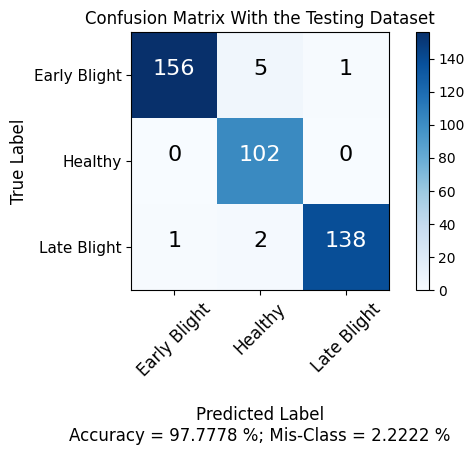

In [13]:
# For the Testing dataset
Y_pred = model.predict(test_generator, verbose = True)
y_pred = np.argmax(Y_pred, axis=1)

print('*** Classification Report ***')
print(classification_report(test_generator.classes, y_pred, target_names=classes_names))

cm = confusion_matrix(test_generator.classes, y_pred)
plot_confusion_matrix(cm,
                     target_names = classes_names,
                     title = "Confusion Matrix With the Testing Dataset")

#**ROC Curve**

In [14]:
def get_roc_auc_score(y_test, y_pred, labels, title="ROC Curve", average="macro"):

    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test = lb.transform(y_test)
    y_pred = lb.transform(y_pred)

    for (idx, c_label) in enumerate(labels): # labels: no of the labels, for ex. ['cat', 'dog', 'rat']
        fpr, tpr, thresholds = roc_curve(y_test[:,idx].astype(int), y_pred[:,idx])
        c_ax.plot(fpr, tpr, label = '%s'  % (c_label))

    c_ax.plot(fpr, fpr, 'b-', label = 'Random Guessing')

    # plot the roc curve for the model
    c_ax.set_ylabel('True Positive Rate', size = 12)
    c_ax.set_xlabel('False Positive Rate',size = 12)
    c_ax.set_title(title)

    # show the legend
    c_ax.legend()

    return roc_auc_score(y_test, y_pred, average=average)


0.9984467195498418

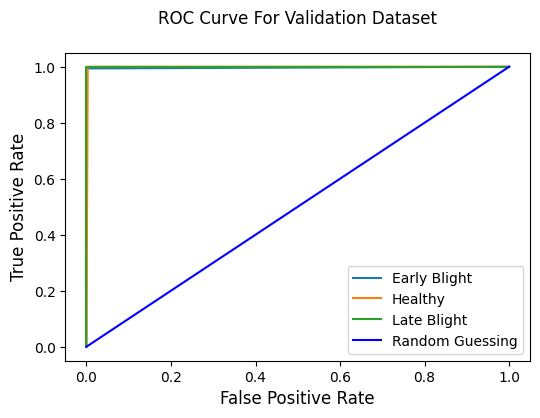

In [15]:
# For Validatoin Dataset
fig, c_ax = plt.subplots(1, 1, figsize = (6,4))
get_roc_auc_score(val_generator.classes, y_pred_val, classes_names, 'ROC Curve For Validation Dataset\n')

0.9851134919769885

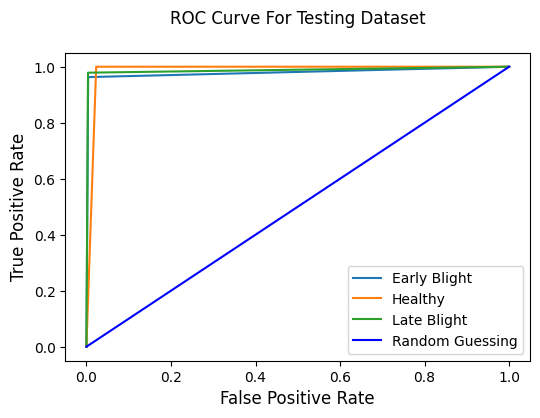

In [16]:
# For Testing Dataset
fig, c_ax = plt.subplots(1, 1, figsize = (6,4))
get_roc_auc_score(test_generator.classes, y_pred, classes_names, "ROC Curve For Testing Dataset\n")